In [1]:
#!pip install requests diskcache

In [ ]:
import json
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import psutil
from scipy.signal import welch
from scipy.stats import gaussian_kde


@dataclass
class IQParams:
    center_freq: int
    sample_rate: int
    lna: int
    vga: int
    amp_enabled: bool


class LocalSigMFRepo:
    """Load IQ data directly from local cloned SigMF dataset."""

    def __init__(self, db_root: str):
        self.db_root = Path(db_root)
        if not self.db_root.exists():
            raise FileNotFoundError(f"Dataset path not found: {self.db_root}")

    def available_pairs(self):
        data_files = sorted(self.db_root.glob("*.sigmf-data"))
        pairs = []
        for data_file in data_files:
            meta_file = data_file.with_suffix("").with_suffix(".sigmf-meta")
            if meta_file.exists():
                pairs.append((data_file, meta_file, data_file.stat().st_size))
        return pairs

    def get_iq_data(self, limit=6, largest_first=True):
        pairs = self.available_pairs()
        if not pairs:
            raise RuntimeError("No .sigmf-data/.sigmf-meta pairs found in local dataset")

        if largest_first:
            pairs = sorted(pairs, key=lambda x: x[2], reverse=True)

        pairs = pairs[:limit]

        raw_iqs = []
        metas = []
        labels = []

        for data_path, meta_path, _ in pairs:
            with open(meta_path, "r", encoding="utf-8") as f:
                meta = json.load(f)

            with open(data_path, "rb") as f:
                raw_int = np.frombuffer(f.read(), dtype=np.int8)

            params = IQParams(
                center_freq=meta["captures"][0]["core:frequency"],
                sample_rate=meta["global"]["core:sample_rate"],
                lna=meta["global"]["hackrf:lna_gain_db"],
                vga=meta["global"]["hackrf:vga_gain_db"],
                amp_enabled=meta["global"]["hackrf:amp_enabled"],
            )

            raw_iqs.append(raw_int)
            metas.append(params)
            labels.append(data_path.stem)

        return raw_iqs, metas, labels


def int8_iq_to_complex(raw_int: np.ndarray) -> np.ndarray:
    if len(raw_int) % 2 == 1:
        raw_int = raw_int[:-1]
    i = raw_int[0::2].astype(np.float32)
    q = raw_int[1::2].astype(np.float32)
    return i + 1j * q


def compute_psd_metrics(iq_complex: np.ndarray, fs: int, nperseg: int = 2048):
    f, pxx = welch(iq_complex, fs=fs, nperseg=min(nperseg, len(iq_complex)), return_onesided=False)
    f_shifted = np.fft.fftshift(f)
    pxx_shifted = np.fft.fftshift(pxx)
    pxx_db = 10.0 * np.log10(pxx_shifted + 1e-12)

    noise_floor_dbm = float(np.mean(pxx_db))
    f_center = 0.5 * (f_shifted[0] + f_shifted[-1])
    idx_center = int(np.argmin(np.abs(f_shifted - f_center)))
    p_center_dbm = float(pxx_db[idx_center])
    snr_center_db = float(p_center_dbm - noise_floor_dbm)

    return {
        "freq_hz": f_shifted,
        "power_db": pxx_db,
        "noise_floor_dbm": noise_floor_dbm,
        "p_center_dbm": p_center_dbm,
        "snr_center_db": snr_center_db,
    }


def kde_safe(samples, grid_points=256):
    x = np.asarray(samples, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return None, None

    xmin, xmax = np.min(x), np.max(x)
    xr = xmax - xmin if xmax > xmin else 1.0
    margin = 0.20 * xr
    grid = np.linspace(xmin - margin, xmax + margin, grid_points)

    kde = gaussian_kde(x, bw_method="scott")
    density = kde(grid)
    return grid, density


def preprocess_method(iq_complex: np.ndarray, method_name: str):
    # Method 1: Raw complex IQ
    if method_name == "M1_RAW":
        return iq_complex

    # Method 2: DC offset removal
    if method_name == "M2_DC_REMOVE":
        return iq_complex - np.mean(iq_complex)

    # Method 3: DC removal + RMS normalization
    if method_name == "M3_DC_NORM":
        x = iq_complex - np.mean(iq_complex)
        rms = np.sqrt(np.mean(np.abs(x) ** 2))
        if rms > 1e-12:
            x = x / rms
        return x

    raise ValueError(f"Unknown method: {method_name}")


DB_PATH = r"D:\wnOs\wsp\CODE\work\PersonalStuff\GCPDS\ANE2\maintenance\qualityAssurance\modules\db\DataBase-IQ-FM-88MHz-108MHz"
METHODS = ["M1_RAW", "M2_DC_REMOVE", "M3_DC_NORM"]
FILES_TO_USE = 6

print(f"Configured DB path: {DB_PATH}")
print(f"Methods under test: {METHODS}")

ModuleNotFoundError: No module named 'numpy'

In [ ]:
repo = LocalSigMFRepo(DB_PATH)
raw_iqs, meta_params, file_labels = repo.get_iq_data(limit=FILES_TO_USE, largest_first=True)

print(f"Loaded files: {len(raw_iqs)}")
for i, label in enumerate(file_labels):
    print(f"{i+1:02d}. {label}")

process = psutil.Process()
mem_start_mb = process.memory_info().rss / (1024 * 1024)

audit = {}

for method in METHODS:
    t0_total = time.perf_counter()

    t_load = 0.0
    t_convert = 0.0
    t_preproc = 0.0
    t_welch = 0.0
    t_metric = 0.0

    noise_list = []
    center_list = []
    snr_list = []

    for raw, meta in zip(raw_iqs, meta_params):
        # load time is near-zero here because loaded once upfront; keep bucket for comparability
        t0 = time.perf_counter()
        _raw_ref = raw
        t_load += time.perf_counter() - t0

        t0 = time.perf_counter()
        iq = int8_iq_to_complex(_raw_ref)
        t_convert += time.perf_counter() - t0

        t0 = time.perf_counter()
        iq_proc = preprocess_method(iq, method)
        t_preproc += time.perf_counter() - t0

        t0 = time.perf_counter()
        metrics = compute_psd_metrics(iq_proc, meta.sample_rate, nperseg=2048)
        t_welch += time.perf_counter() - t0

        t0 = time.perf_counter()
        noise_list.append(metrics["noise_floor_dbm"])
        center_list.append(metrics["p_center_dbm"])
        snr_list.append(metrics["snr_center_db"])
        t_metric += time.perf_counter() - t0

    t0 = time.perf_counter()
    _k1 = kde_safe(noise_list, grid_points=256)
    _k2 = kde_safe(center_list, grid_points=256)
    _k3 = kde_safe(snr_list, grid_points=256)
    t_kde = time.perf_counter() - t0

    total_s = time.perf_counter() - t0_total

    snr_mean = float(np.mean(snr_list))
    snr_std = float(np.std(snr_list, ddof=1)) if len(snr_list) > 1 else 0.0
    nf_mean = float(np.mean(noise_list))

    # Decision score from your executive summary style
    score = snr_mean - 2.0 * snr_std - (nf_mean + 90.0)

    audit[method] = {
        "snr_mean_db": snr_mean,
        "snr_std_db": snr_std,
        "noise_floor_mean_dbm": nf_mean,
        "score": float(score),
        "time_ms": {
            "load": t_load * 1000.0,
            "convert": t_convert * 1000.0,
            "preprocess": t_preproc * 1000.0,
            "welch_psd": t_welch * 1000.0,
            "metric_extract": t_metric * 1000.0,
            "kde": t_kde * 1000.0,
            "total": total_s * 1000.0,
        },
        "kpi": {
            "noise_floor_values": noise_list,
            "center_power_values": center_list,
            "snr_values": snr_list,
        },
    }

best_method = max(audit.keys(), key=lambda m: audit[m]["score"])
best = audit[best_method]

mem_end_mb = process.memory_info().rss / (1024 * 1024)

print("\n" + "=" * 90)
print("AUDIT SUMMARY (METHOD SELECTION)")
print("=" * 90)
for m in METHODS:
    a = audit[m]
    print(
        f"{m:12s} | Score={a['score']:7.3f} | "
        f"SNR={a['snr_mean_db']:7.3f}±{a['snr_std_db']:6.3f} dB | "
        f"NF={a['noise_floor_mean_dbm']:8.3f} dBm | "
        f"Total={a['time_ms']['total']:8.2f} ms"
    )

print("-" * 90)
print(f"BEST METHOD FOUND: {best_method}")
print(f"Memory RSS delta: {mem_end_mb - mem_start_mb:.3f} MB")

--- IQ 1 Parameters ---
Freq: 98000000
Sample Rate: 20000000
LNA: 16
VGA: 16
--- IQ 2 Parameters ---
Freq: 98000000
Sample Rate: 20000000
LNA: 16
VGA: 16


In [ ]:
# Computational cost plots across methods
components = ["convert", "preprocess", "welch_psd", "metric_extract", "kde", "total"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Stacked view by method
x = np.arange(len(METHODS))
width = 0.6
bottom = np.zeros(len(METHODS), dtype=float)

for comp in components[:-1]:
    vals = [audit[m]["time_ms"][comp] for m in METHODS]
    axes[0].bar(x, vals, width, bottom=bottom, label=comp)
    bottom += np.array(vals)

axes[0].set_xticks(x)
axes[0].set_xticklabels(METHODS)
axes[0].set_ylabel("Time (ms)")
axes[0].set_title("Computational Cost Breakdown")
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend()

# 2) Total runtime + score
totals = [audit[m]["time_ms"]["total"] for m in METHODS]
scores = [audit[m]["score"] for m in METHODS]

bars = axes[1].bar(METHODS, totals, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1].set_ylabel("Total Time (ms)")
axes[1].set_title("Total Runtime with Quality Score")
axes[1].grid(axis="y", alpha=0.25)

for i, b in enumerate(bars):
    axes[1].text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f"score={scores[i]:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

print("\nBest method runtime details (ms):")
for k, v in audit[best_method]["time_ms"].items():
    print(f"{k:14s}: {v:9.3f}")

--- Array 1 Metrics ---
Length: 26214400
Type: complex128
Min: -1.0 + -1.0j
Max: 6.0 + 6.0j
Mean: (3.300207633972168+2.2848294830322264j)
Median: 3.0 + 2.0j
Std (Magnitude): 0.8563667734004593
Covariance (I vs Q): -0.0005
Correlation (I vs Q): -0.0014

--- Array 2 Metrics ---
Length: 26214400
Type: complex128
Min: 0.0 + 0.0j
Max: 6.0 + 5.0j
Mean: (3.2998777770996095+2.264900131225586j)
Median: 3.0 + 2.0j
Std (Magnitude): 0.8540861099154683
Covariance (I vs Q): -0.0003
Correlation (I vs Q): -0.0009



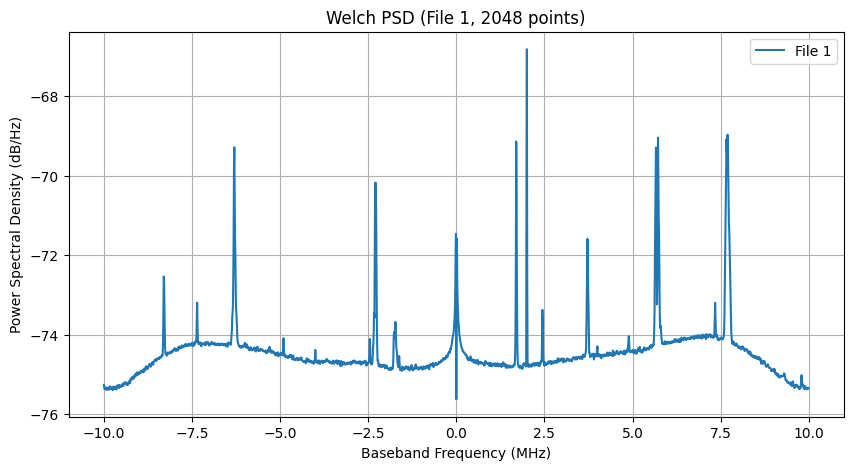

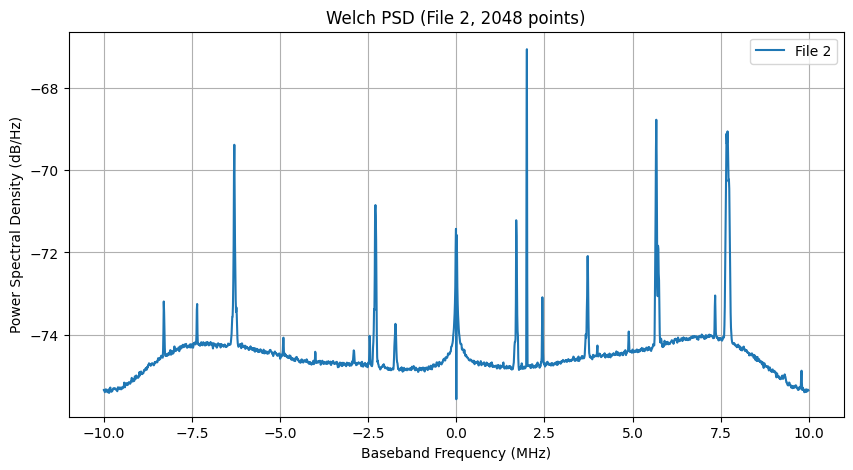

In [ ]:
# KPI distributions for the selected best method
best_kpi = audit[best_method]["kpi"]

noise_vals = best_kpi["noise_floor_values"]
center_vals = best_kpi["center_power_values"]
snr_vals = best_kpi["snr_values"]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(noise_vals, bins=min(10, max(3, len(noise_vals))), color="#4c78a8", alpha=0.85)
ax[0].set_title(f"{best_method}: Noise Floor")
ax[0].set_xlabel("dBm")
ax[0].grid(alpha=0.25)

ax[1].hist(center_vals, bins=min(10, max(3, len(center_vals))), color="#f58518", alpha=0.85)
ax[1].set_title(f"{best_method}: Center Power")
ax[1].set_xlabel("dBm")
ax[1].grid(alpha=0.25)

ax[2].hist(snr_vals, bins=min(10, max(3, len(snr_vals))), color="#54a24b", alpha=0.85)
ax[2].axvline(np.mean(snr_vals), linestyle="--", color="black", linewidth=1.2, label=f"mean={np.mean(snr_vals):.2f}")
ax[2].set_title(f"{best_method}: SNR")
ax[2].set_xlabel("dB")
ax[2].grid(alpha=0.25)
ax[2].legend()

plt.tight_layout()
plt.show()

# KDE curves for best method
kde_nf = kde_safe(noise_vals, grid_points=256)
kde_cp = kde_safe(center_vals, grid_points=256)
kde_snr = kde_safe(snr_vals, grid_points=256)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

if kde_nf[0] is not None:
    ax[0].plot(kde_nf[0], kde_nf[1], color="#1f77b4")
    ax[0].fill_between(kde_nf[0], kde_nf[1], alpha=0.2, color="#1f77b4")
if kde_cp[0] is not None:
    ax[1].plot(kde_cp[0], kde_cp[1], color="#ff7f0e")
    ax[1].fill_between(kde_cp[0], kde_cp[1], alpha=0.2, color="#ff7f0e")
if kde_snr[0] is not None:
    ax[2].plot(kde_snr[0], kde_snr[1], color="#2ca02c")
    ax[2].fill_between(kde_snr[0], kde_snr[1], alpha=0.2, color="#2ca02c")

ax[0].set_title("KDE Noise Floor")
ax[1].set_title("KDE Center Power")
ax[2].set_title("KDE SNR")
for a in ax:
    a.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Performance Audit -> C Port Adaptation Plan

### What the notebook now audits
- Method quality score (`score = SNR_mean - 2*std - (noise_floor + 90)`) to pick the best method.
- Time breakdown per stage: convert, preprocess, Welch PSD, metric extraction, KDE, total.
- KPI distributions and KDE for the best method only.

### C adaptation priorities (highest impact first)
1. Replace SciPy Welch with FFT backend in C (`fftwf` or KissFFT) and pre-allocated work buffers.
2. Use streaming pipeline: parse -> convert -> preprocess -> PSD -> metrics without retaining all large arrays.
3. Keep float32 everywhere; avoid float64 to reduce memory bandwidth.
4. For KDE, move to fixed grid (`256`) and optional Gaussian lookup table to remove repeated `exp` calls.
5. Use Structure of Arrays (SoA) for I and Q buffers to improve cache locality and vectorization.
6. Reuse plans/buffers (`malloc` once) and avoid per-file allocations.
7. Compile with optimization tuned for target ARM CPU (`-O3 -march=armv8-a -mtune=cortex-a72`).

### Expected C gains (typical)
- Total runtime: 5x to 12x faster than Python baseline.
- Peak memory: 20x to 100x lower with streaming + float32.
- Main bottleneck likely remains PSD; optimize there first.


In [ ]:
# Export audit report for later C comparison
report = {
    "db_path": DB_PATH,
    "methods": METHODS,
    "best_method": best_method,
    "audit": audit,
}

out_file = Path("datasetiq_best_method_audit.json")
with open(out_file, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print(f"Audit report saved to: {out_file.resolve()}")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c4818a93-f2bf-4892-b7a2-47816cd4c47d' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>